In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
## Loading each countries clean csv and concatinating
countries = ['ethiopia', 'kenya', 'sudan', 'tanzania', 'nigeria']
all_data = []

for country in countries:
    # Load the cleaned file
    df_temp = pd.read_csv(f'../data/{country}_clean.csv')
    # Ensure the Date column is back in datetime format after loading from CSV
    df_temp['Date'] = pd.to_datetime(df_temp['Date'])
    all_data.append(df_temp)

# Concatenate into one big DataFrame
df_all = pd.concat(all_data, ignore_index=True)

df_all.head()


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


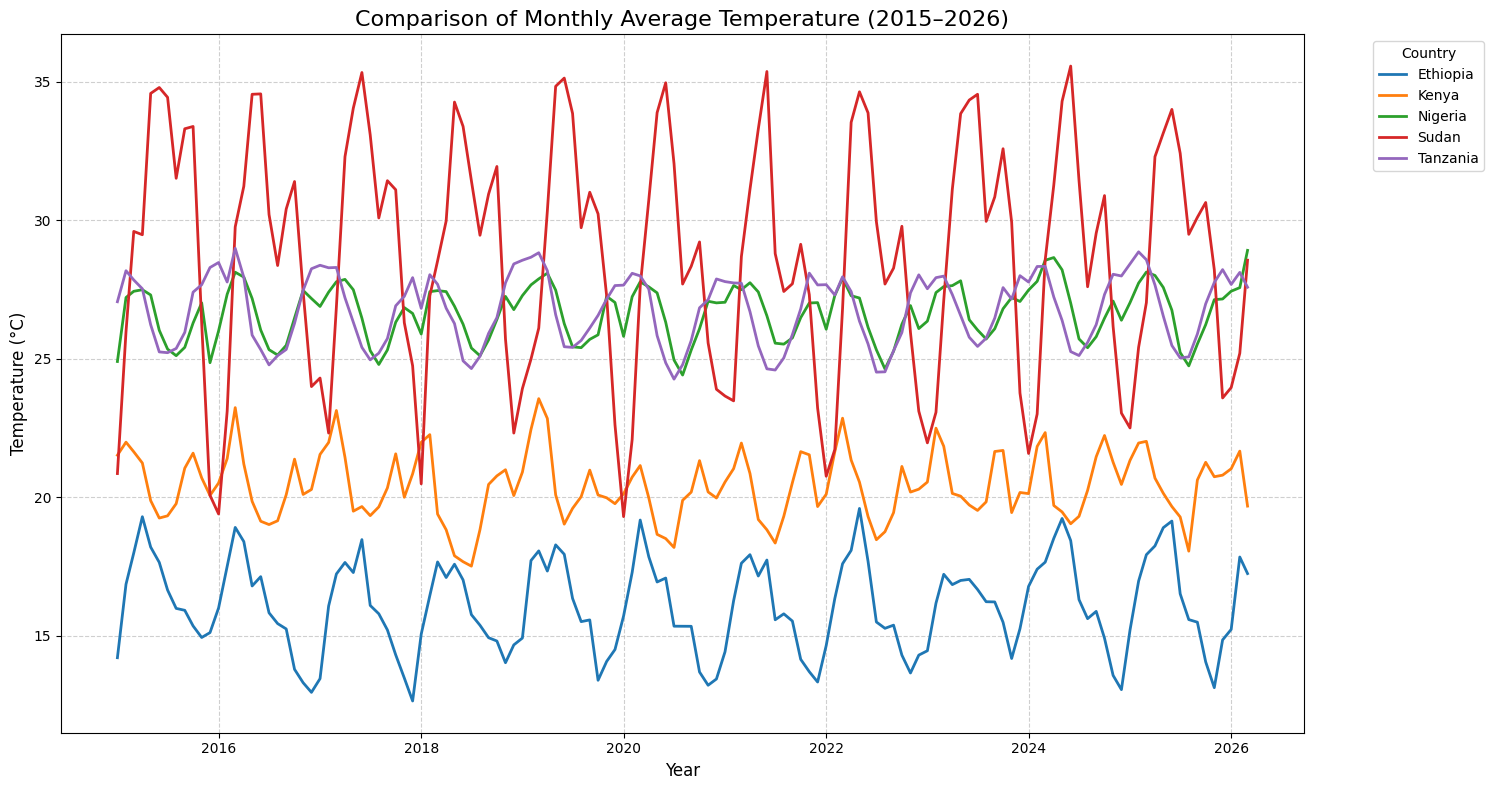

In [16]:
##Temperature Trend Comparison
# Create a Year-Month column for grouping
df_all['YearMonth'] = df_all['Date'].dt.to_period('M').dt.to_timestamp()

# Calculate monthly average temperature per country
df_monthly_comp = df_all.groupby(['YearMonth', 'Country'])['T2M'].mean().reset_index()

plt.figure(figsize=(15, 8))

# Use 'hue' to give each country its own line and color
sns.lineplot(data=df_monthly_comp, x='YearMonth', y='T2M', hue='Country', linewidth=2)

plt.title('Comparison of Monthly Average Temperature (2015–2026)', fontsize=16)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(title='Country', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()


In [17]:
# Group by Country and calculate mean, median, and std for Temperature (T2M)
temp_summary = df_all.groupby('Country')['T2M'].agg(['mean', 'median', 'std']).reset_index()

# Round to 2 decimal places for a professional look
temp_summary = temp_summary.round(2)

# Rename columns for clarity
temp_summary.columns = ['Country', 'Mean Temp (°C)', 'Median Temp (°C)', 'Std Dev (Volatility)']

# Sort by Mean Temp to see the ranking clearly
temp_summary = temp_summary.sort_values(by='Mean Temp (°C)', ascending=False)

print(temp_summary)

    Country  Mean Temp (°C)  Median Temp (°C)  Std Dev (Volatility)
3     Sudan           28.76             29.16                  4.68
4  Tanzania           26.80             26.99                  1.33
2   Nigeria           26.66             26.82                  1.12
1     Kenya           20.43             20.36                  1.44
0  Ethiopia           16.07             16.04                  1.90


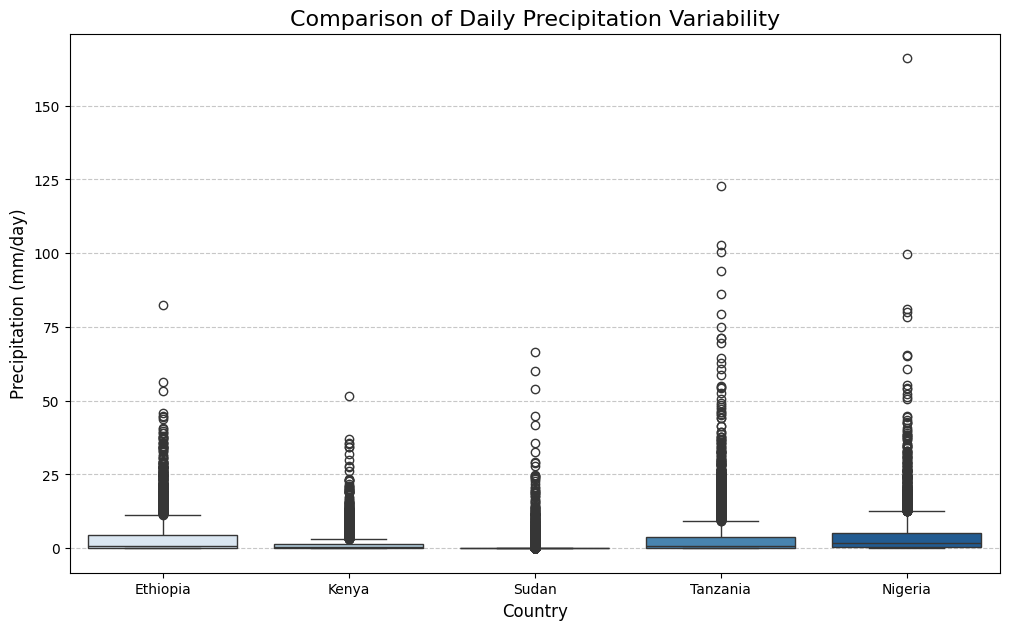

In [20]:
plt.figure(figsize=(12, 7))

# Updated line: assign 'Country' to 'hue' and set 'legend=False'
sns.boxplot(data=df_all, x='Country', y='PRECTOTCORR', hue='Country', palette='Blues', legend=False)

plt.title('Comparison of Daily Precipitation Variability', fontsize=16)
plt.xlabel('Country', fontsize=12)
plt.ylabel('Precipitation (mm/day)', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.show()

In [19]:
# Group by Country and calculate stats for Precipitation
precip_summary = df_all.groupby('Country')['PRECTOTCORR'].agg(['mean', 'median', 'std']).reset_index()

# Round for readability
precip_summary = precip_summary.round(2)

# Rename columns
precip_summary.columns = ['Country', 'Mean Rain (mm)', 'Median Rain (mm)', 'Std Dev (Variability)']

# Sort by variability (Std Dev) to see which country has the most 'chaotic' rain
precip_summary = precip_summary.sort_values(by='Std Dev (Variability)', ascending=False)

print(precip_summary)

    Country  Mean Rain (mm)  Median Rain (mm)  Std Dev (Variability)
4  Tanzania            3.74              0.64                   8.00
2   Nigeria            4.21              1.84                   7.27
0  Ethiopia            3.63              0.82                   6.29
1     Kenya            1.47              0.38                   3.18
3     Sudan            0.64              0.00                   3.06
